## 03 - Intermediate Fusion: Model Analysis & Comparison

This notebook evaluates the intermediate fusion model (per-modality encoders → latent
concatenation → MLP classifier) and compares it against the XGBoost and RandomForest
baselines.

**Contents:**
1. Setup & configuration
2. Model architecture summary
3. Training curves (all folds)
4. Per-fold metrics
5. Three-model comparison table
6. Comparison bar charts
7. `model_comparison.csv` export (Streamlit-compatible)
8. Confusion matrices
9. Discussion

> *Academic research prototype. Not for clinical use.*

---
### 1. Setup

In [1]:
import os, sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch

# Project root
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.utils import set_seeds, load_config
from src.models import IntermediateFusionModel

set_seeds(42)
config = load_config()

CANCER_TYPES = config['project']['cancer_types']
METRICS_DIR = os.path.join(config['paths']['results'], 'metrics')
PLOTS_DIR = os.path.join(config['paths']['results'], 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titleweight': 'bold',
})

print(f'Cancer types: {CANCER_TYPES}')
print(f'Device: {"cuda" if torch.cuda.is_available() else "cpu"}')

Cancer types: ['GS-BRCA', 'GS-COAD']
Device: cuda


---
### 2. Model Architecture

In [2]:
# Load a saved checkpoint to recover exact architecture parameters
brca_ckpt = torch.load(
    os.path.join(config['paths']['models'], 'intermediate_fusion', 'fusion_brca_fold0.pt'),
    map_location='cpu', weights_only=False,
)

modality_dims = brca_ckpt['modality_dims']
latent_dim = brca_ckpt['latent_dim']
num_classes = brca_ckpt['num_classes']
encoder_hidden = brca_ckpt['encoder_hidden']
classifier_hidden = brca_ckpt['classifier_hidden']
dropout = brca_ckpt['dropout']

print('=== Architecture Parameters (GS-BRCA) ===')
print(f'Modality dimensions: {modality_dims}')
print(f'Encoder hidden dim:  {encoder_hidden}')
print(f'Latent dim per mod:  {latent_dim}')
print(f'Total latent dim:    {latent_dim * len(modality_dims)}')
print(f'Classifier hidden:   {classifier_hidden}')
print(f'Dropout:             {dropout}')
print(f'Num classes:         {num_classes}')

=== Architecture Parameters (GS-BRCA) ===
Modality dimensions: {'mrna': 5000, 'mirna': 366, 'methy': 5000, 'cnv': 5000}
Encoder hidden dim:  256
Latent dim per mod:  64
Total latent dim:    256
Classifier hidden:   128
Dropout:             0.3
Num classes:         5


In [3]:
# Instantiate and print full model summary
model = IntermediateFusionModel(
    modality_dims=modality_dims,
    latent_dim=latent_dim,
    hidden_dim=classifier_hidden,
    num_classes=num_classes,
    dropout=dropout,
    encoder_hidden=encoder_hidden,
)

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('=== Model Architecture ===')
print(model)
print(f'\nTotal parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable:,}')

=== Model Architecture ===
IntermediateFusionModel(
  (encoders): ModuleDict(
    (mrna): ModalityEncoder(
      (encoder): Sequential(
        (0): Linear(in_features=5000, out_features=256, bias=True)
        (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Dropout(p=0.3, inplace=False)
        (4): Linear(in_features=256, out_features=64, bias=True)
        (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): ReLU(inplace=True)
      )
    )
    (mirna): ModalityEncoder(
      (encoder): Sequential(
        (0): Linear(in_features=366, out_features=256, bias=True)
        (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Dropout(p=0.3, inplace=False)
        (4): Linear(in_features=256, out_features=64, bias=True)
        (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True

In [4]:
# Per-encoder parameter breakdown
print('=== Per-Component Breakdown ===')
for name, encoder in model.encoders.items():
    n = sum(p.numel() for p in encoder.parameters())
    print(f'  {name:6s} encoder: {n:>10,} params  (input={modality_dims[name]})')

clf_params = sum(p.numel() for p in model.classifier.parameters())
print(f'  classifier:      {clf_params:>10,} params')
print(f'  TOTAL:           {total_params:>10,} params')

=== Per-Component Breakdown ===
  mrna   encoder:  1,297,344 params  (input=5000)
  mirna  encoder:    111,040 params  (input=366)
  methy  encoder:  1,297,344 params  (input=5000)
  cnv    encoder:  1,297,344 params  (input=5000)
  classifier:          33,541 params
  TOTAL:            4,036,613 params


---
### 3. Training Curves

Training curves were saved during `scripts/train_fusion.py`. We display them inline
for both cancer types.

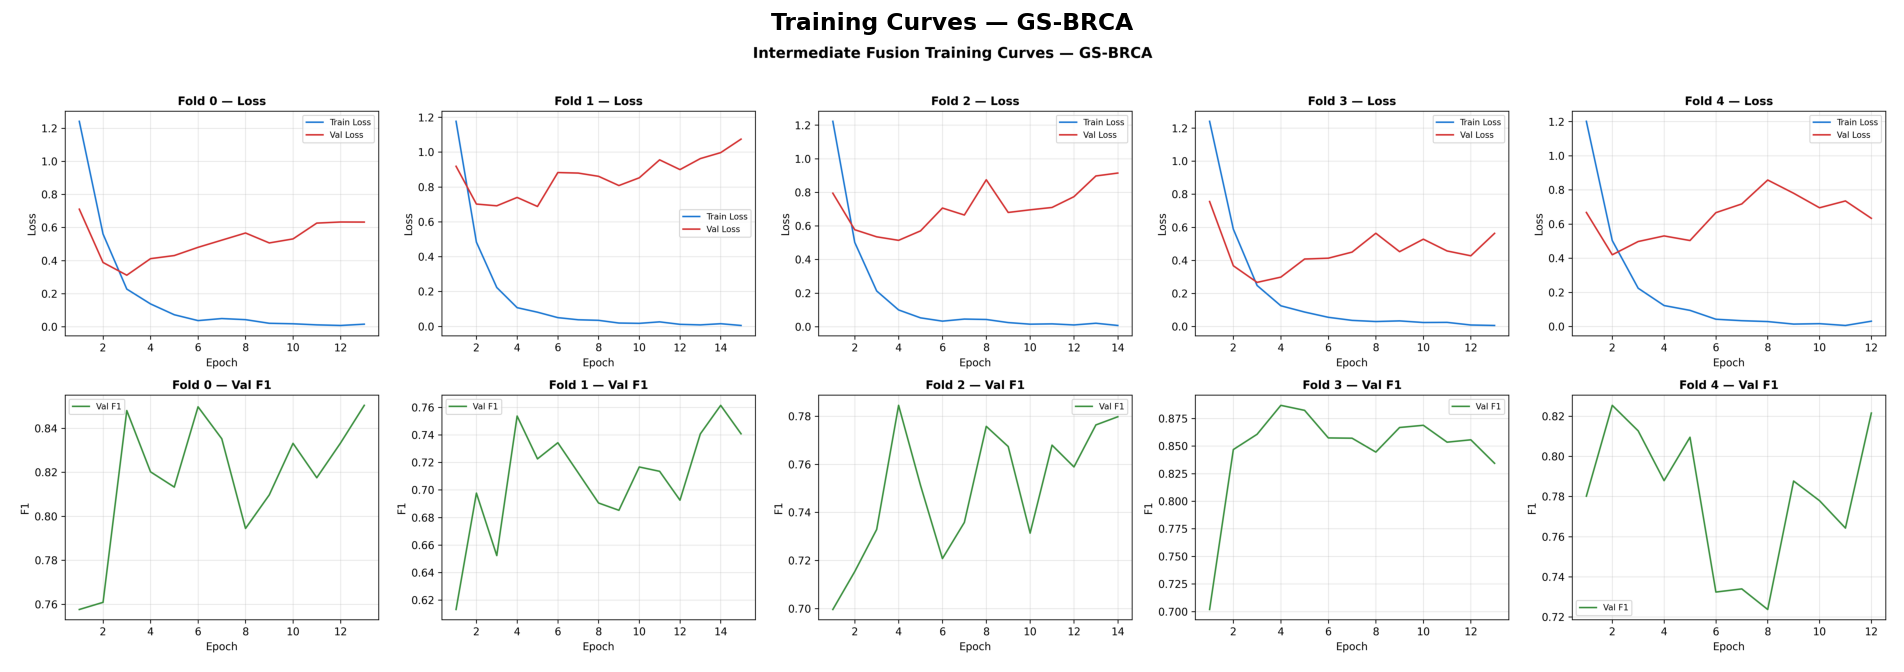

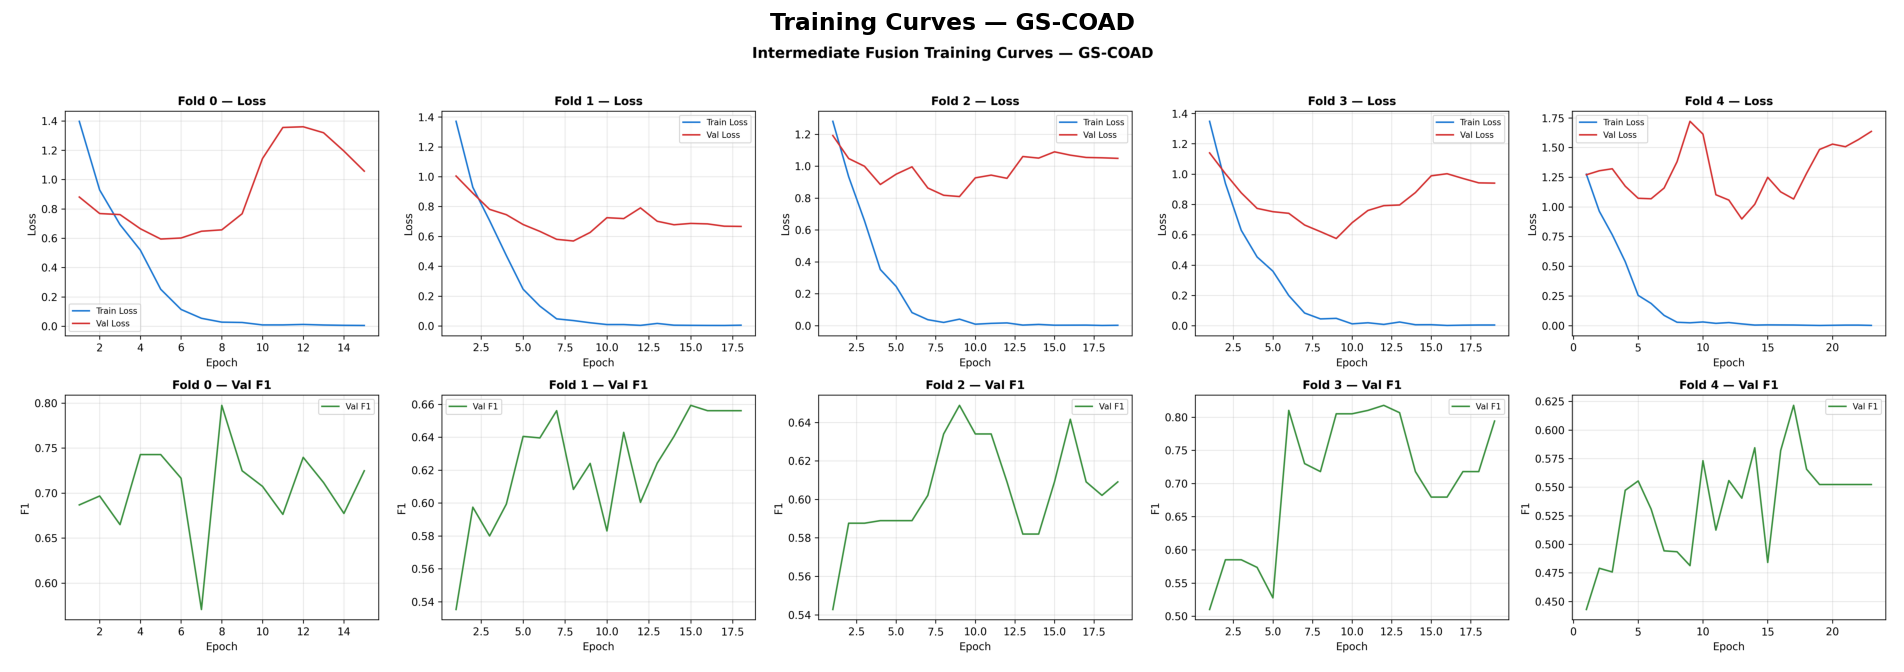

In [5]:
for ct in CANCER_TYPES:
    cancer_short = ct.split('-')[1]
    img_path = os.path.join(PLOTS_DIR, f'fusion_training_curves_{cancer_short}.png')
    if os.path.exists(img_path):
        img = plt.imread(img_path)
        fig, ax = plt.subplots(figsize=(16, 6))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f'Training Curves — {ct}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print(f'Training curves not found for {ct}: {img_path}')

---
### 4. Per-Fold Fusion Metrics

In [6]:
def load_metrics(model_prefix, cancer_short):
    """Load metrics CSV and parse mean/std from summary row."""
    path = os.path.join(METRICS_DIR, f'{model_prefix}_{cancer_short}_metrics.csv')
    if not os.path.exists(path):
        print(f'Not found: {path}')
        return None
    df = pd.read_csv(path)
    return df


def parse_summary_row(df):
    """Extract mean and std from the summary row of a metrics CSV."""
    summary = df[df['fold'] == 'mean+/-std']
    if len(summary) == 0:
        return None
    row = summary.iloc[0]
    result = {}
    for metric in ['precision', 'recall', 'f1', 'nmi', 'ari']:
        val = str(row.get(metric, ''))
        if '+/-' in val:
            mean_str, std_str = val.split('+/-')
            result[f'{metric}_mean'] = float(mean_str)
            result[f'{metric}_std'] = float(std_str)
        else:
            result[f'{metric}_mean'] = float(val) if val else 0.0
            result[f'{metric}_std'] = 0.0
    return result

In [7]:
# Show fusion per-fold metrics for each cancer
for ct in CANCER_TYPES:
    cancer_short = ct.split('-')[1].lower()
    df = load_metrics('fusion', cancer_short)
    if df is not None:
        print(f'\n=== Intermediate Fusion: {ct} ===')
        fold_rows = df[df['fold'] != 'mean+/-std'].copy()
        for col in ['precision', 'recall', 'f1', 'nmi', 'ari', 'accuracy']:
            fold_rows[col] = pd.to_numeric(fold_rows[col], errors='coerce')
        display_cols = ['fold', 'precision', 'recall', 'f1', 'nmi', 'ari', 'accuracy']
        print(fold_rows[display_cols].to_string(index=False, float_format='%.4f'))

        summary = parse_summary_row(df)
        if summary:
            print(f"\nMean F1:  {summary['f1_mean']:.4f} ± {summary['f1_std']:.4f}")
            print(f"Mean Acc: {fold_rows['accuracy'].mean():.4f} ± {fold_rows['accuracy'].std():.4f}")


=== Intermediate Fusion: GS-BRCA ===
fold  precision  recall     f1    nmi    ari  accuracy
   0     0.8401  0.8571 0.8480 0.6675 0.6501    0.8593
   1     0.7187  0.7955 0.7226 0.5658 0.4497    0.7463
   2     0.7808  0.8024 0.7845 0.6604 0.6825    0.8507
   3     0.8273  0.9224 0.8606 0.7266 0.6772    0.8731
   4     0.7916  0.8733 0.8254 0.6221 0.6047    0.8358

Mean F1:  0.8082 ± 0.0500
Mean Acc: 0.8330 ± 0.0504

=== Intermediate Fusion: GS-COAD ===
fold  precision  recall     f1    nmi    ari  accuracy
   0     0.7159  0.7905 0.7427 0.4428 0.4915    0.8077
   1     0.6036  0.6202 0.6083 0.5945 0.6531    0.8654
   2     0.6315  0.6722 0.6489 0.6907 0.7872    0.9038
   3     0.8301  0.7873 0.8051 0.5941 0.6384    0.8462
   4     0.5180  0.5947 0.5403 0.4194 0.4678    0.7692

Mean F1:  0.6691 ± 0.0944
Mean Acc: 0.8385 ± 0.0520


---
### 5. Three-Model Comparison Table

Compare XGBoost (early fusion), RandomForest (early fusion), and Intermediate Fusion
on the same patient-level stratified 5-fold CV splits.

In [8]:
MODEL_MAP = {
    'XGBoost': 'xgb',
    'RandomForest': 'rf',
    'IntermediateFusion': 'fusion',
}

rows = []
for ct in CANCER_TYPES:
    cancer_short = ct.split('-')[1].lower()
    for model_name, prefix in MODEL_MAP.items():
        df = load_metrics(prefix, cancer_short)
        if df is None:
            continue
        summary = parse_summary_row(df)
        if summary is None:
            continue
        row = {'Model': model_name, 'Cancer': ct}
        for metric in ['f1', 'precision', 'recall', 'nmi', 'ari']:
            row[f'{metric.upper()}_mean'] = summary[f'{metric}_mean']
            row[f'{metric.upper()}_std'] = summary[f'{metric}_std']
        rows.append(row)

comparison_df = pd.DataFrame(rows)
comparison_df

,Model,Cancer,F1_mean,F1_std,PRECISION_mean,PRECISION_std,RECALL_mean,RECALL_std,NMI_mean,NMI_std,ARI_mean,ARI_std
0,XGBoost,GS-BRCA,0.7939,0.0472,0.8579,0.0426,0.7745,0.0467,0.6637,0.0476,0.6781,0.0322
1,RandomForest,GS-BRCA,0.6023,0.0830,0.8001,0.1345,0.5603,0.0603,0.5477,0.0543,0.4972,0.0600
2,IntermediateFusion,GS-BRCA,0.8082,0.0500,0.7917,0.0426,0.8501,0.0470,0.6485,0.0532,0.6128,0.0861
3,XGBoost,GS-COAD,0.6358,0.1149,0.6694,0.1261,0.6244,0.1125,0.6597,0.1416,0.7366,0.1160
4,RandomForest,GS-COAD,0.6083,0.0733,0.6989,0.1104,0.5950,0.0672,0.5959,0.0940,0.7020,0.0670
5,IntermediateFusion,GS-COAD,0.6691,0.0944,0.6598,0.1060,0.6930,0.0822,0.5483,0.1022,0.6076,0.1169


In [9]:
# Formatted display with mean ± std strings
for ct in CANCER_TYPES:
    ct_data = comparison_df[comparison_df['Cancer'] == ct].copy()
    print(f'\n{"="*60}')
    print(f'  {ct} — Model Comparison (5-Fold CV, mean ± std)')
    print(f'{"="*60}')

    display_data = []
    for _, r in ct_data.iterrows():
        display_data.append({
            'Model': r['Model'],
            'F1': f"{r['F1_mean']:.4f}±{r['F1_std']:.4f}",
            'Precision': f"{r['PRECISION_mean']:.4f}±{r['PRECISION_std']:.4f}",
            'Recall': f"{r['RECALL_mean']:.4f}±{r['RECALL_std']:.4f}",
            'NMI': f"{r['NMI_mean']:.4f}±{r['NMI_std']:.4f}",
            'ARI': f"{r['ARI_mean']:.4f}±{r['ARI_std']:.4f}",
        })
    display_df = pd.DataFrame(display_data)
    print(display_df.to_string(index=False))


  GS-BRCA — Model Comparison (5-Fold CV, mean ± std)
             Model            F1     Precision        Recall           NMI           ARI
           XGBoost 0.7939±0.0472 0.8579±0.0426 0.7745±0.0467 0.6637±0.0476 0.6781±0.0322
      RandomForest 0.6023±0.0830 0.8001±0.1345 0.5603±0.0603 0.5477±0.0543 0.4972±0.0600
IntermediateFusion 0.8082±0.0500 0.7917±0.0426 0.8501±0.0470 0.6485±0.0532 0.6128±0.0861

  GS-COAD — Model Comparison (5-Fold CV, mean ± std)
             Model            F1     Precision        Recall           NMI           ARI
           XGBoost 0.6358±0.1149 0.6694±0.1261 0.6244±0.1125 0.6597±0.1416 0.7366±0.1160
      RandomForest 0.6083±0.0733 0.6989±0.1104 0.5950±0.0672 0.5959±0.0940 0.7020±0.0670
IntermediateFusion 0.6691±0.0944 0.6598±0.1060 0.6930±0.0822 0.5483±0.1022 0.6076±0.1169


---
### 6. Comparison Bar Charts

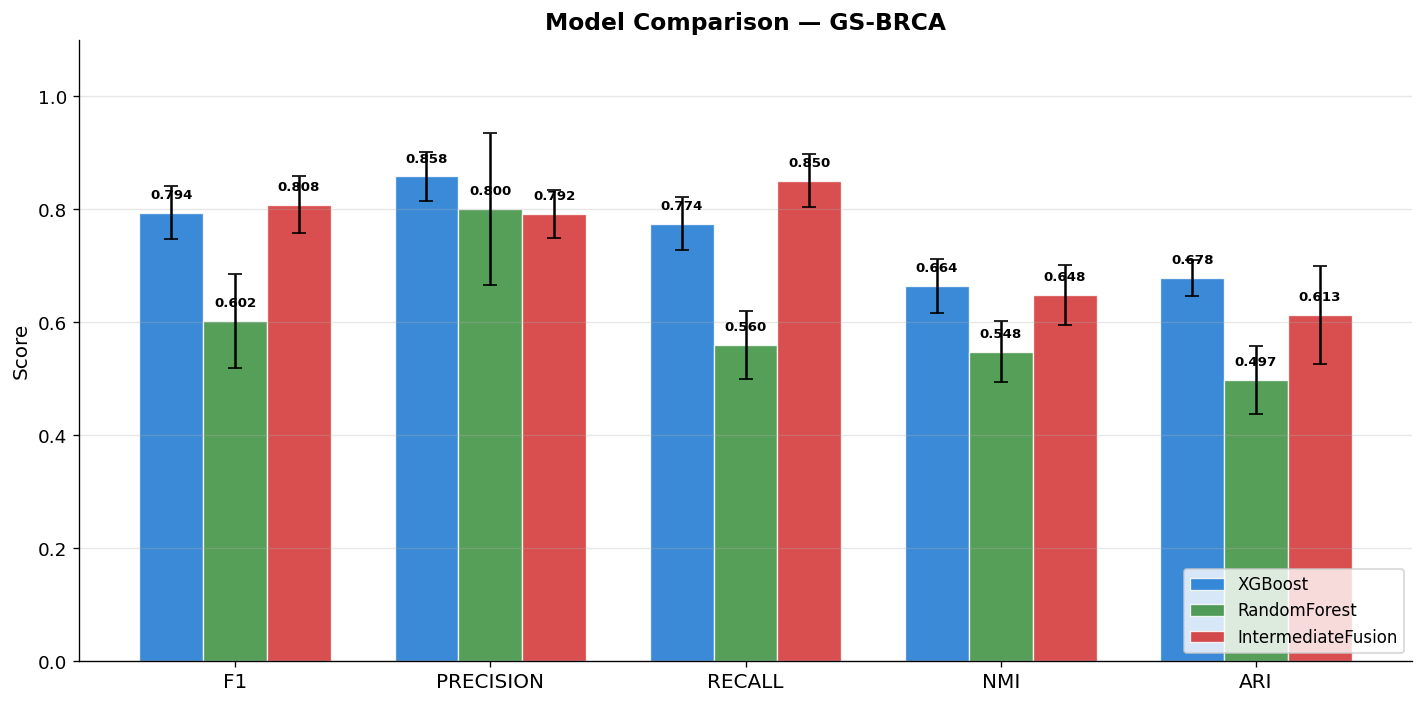

Saved: model_comparison_BRCA.png/pdf


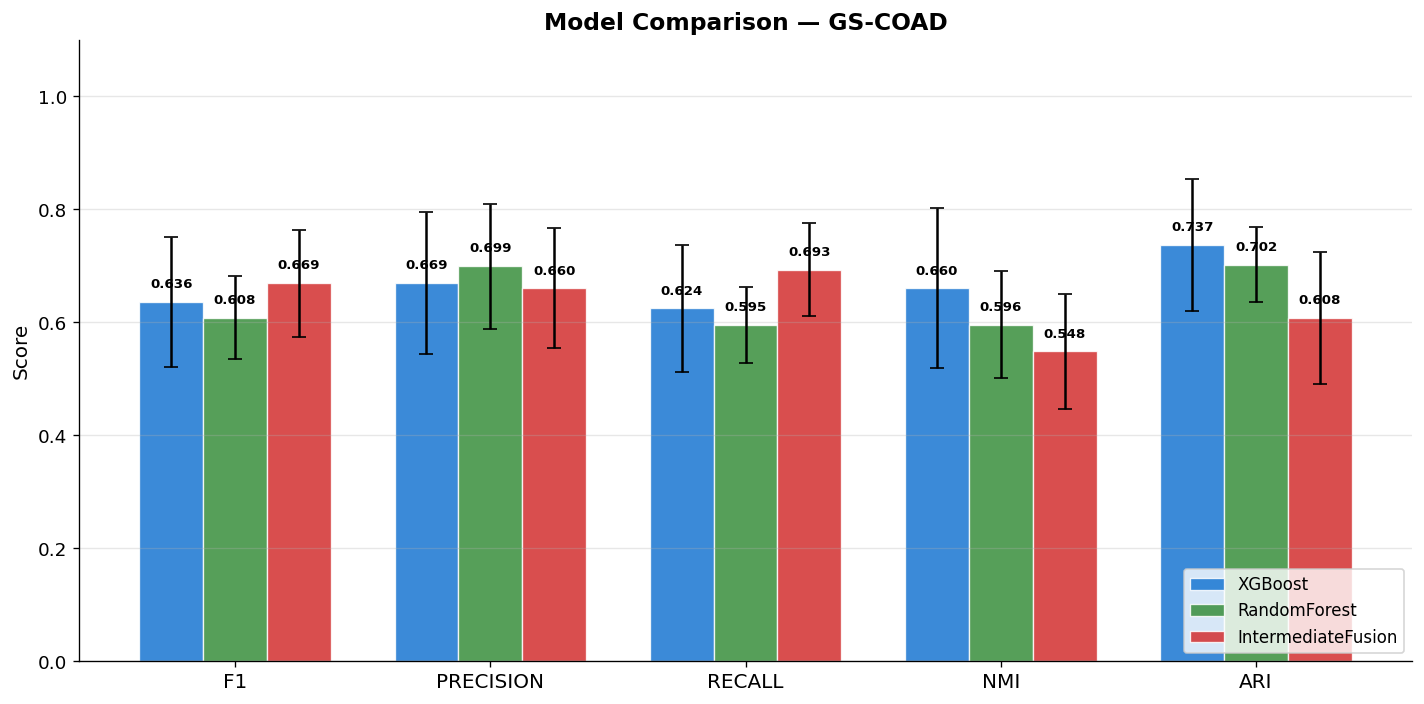

Saved: model_comparison_COAD.png/pdf


In [10]:
METRIC_COLS = ['F1', 'PRECISION', 'RECALL', 'NMI', 'ARI']
MODEL_COLORS = {
    'XGBoost': '#1976D2',
    'RandomForest': '#388E3C',
    'IntermediateFusion': '#D32F2F',
}

for ct in CANCER_TYPES:
    cancer_short = ct.split('-')[1]
    ct_data = comparison_df[comparison_df['Cancer'] == ct]

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(METRIC_COLS))
    width = 0.25

    for i, (_, row) in enumerate(ct_data.iterrows()):
        means = [row[f'{m}_mean'] for m in METRIC_COLS]
        stds = [row[f'{m}_std'] for m in METRIC_COLS]
        bars = ax.bar(
            x + (i - 1) * width, means, width,
            yerr=stds, capsize=4,
            label=row['Model'],
            color=MODEL_COLORS[row['Model']],
            alpha=0.85, edgecolor='white', linewidth=0.8,
        )
        for bar, val in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(METRIC_COLS, fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'Model Comparison — {ct}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, loc='lower right')
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

    for ext in ['png', 'pdf']:
        fig.savefig(os.path.join(PLOTS_DIR, f'model_comparison_{cancer_short}.{ext}'),
                    dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: model_comparison_{cancer_short}.png/pdf')

---
### 7. Export `model_comparison.csv`

Exact columns required by the Streamlit demo:
`Model, Cancer, F1_mean, F1_std, Precision_mean, Precision_std, Recall_mean, Recall_std, NMI_mean, NMI_std, ARI_mean, ARI_std`

In [11]:
# Rename columns to match required Streamlit schema
export_df = comparison_df.rename(columns={
    'F1_mean': 'F1_mean', 'F1_std': 'F1_std',
    'PRECISION_mean': 'Precision_mean', 'PRECISION_std': 'Precision_std',
    'RECALL_mean': 'Recall_mean', 'RECALL_std': 'Recall_std',
    'NMI_mean': 'NMI_mean', 'NMI_std': 'NMI_std',
    'ARI_mean': 'ARI_mean', 'ARI_std': 'ARI_std',
})

EXPORT_COLS = [
    'Model', 'Cancer',
    'F1_mean', 'F1_std',
    'Precision_mean', 'Precision_std',
    'Recall_mean', 'Recall_std',
    'NMI_mean', 'NMI_std',
    'ARI_mean', 'ARI_std',
]
export_df = export_df[EXPORT_COLS]

csv_path = os.path.join(METRICS_DIR, 'model_comparison.csv')
export_df.to_csv(csv_path, index=False, float_format='%.4f')

print(f'Saved: {csv_path}')
print(f'Columns: {list(export_df.columns)}')
print()
print(export_df.to_string(index=False))

Saved: results\metrics\model_comparison.csv
Columns: ['Model', 'Cancer', 'F1_mean', 'F1_std', 'Precision_mean', 'Precision_std', 'Recall_mean', 'Recall_std', 'NMI_mean', 'NMI_std', 'ARI_mean', 'ARI_std']

             Model  Cancer  F1_mean  F1_std  Precision_mean  Precision_std  Recall_mean  Recall_std  NMI_mean  NMI_std  ARI_mean  ARI_std
           XGBoost GS-BRCA   0.7939  0.0472          0.8579         0.0426       0.7745      0.0467    0.6637   0.0476    0.6781   0.0322
      RandomForest GS-BRCA   0.6023  0.0830          0.8001         0.1345       0.5603      0.0603    0.5477   0.0543    0.4972   0.0600
IntermediateFusion GS-BRCA   0.8082  0.0500          0.7917         0.0426       0.8501      0.0470    0.6485   0.0532    0.6128   0.0861
           XGBoost GS-COAD   0.6358  0.1149          0.6694         0.1261       0.6244      0.1125    0.6597   0.1416    0.7366   0.1160
      RandomForest GS-COAD   0.6083  0.0733          0.6989         0.1104       0.5950      0.0672    0.

---
## 8. Confusion Matrices (Best Folds)

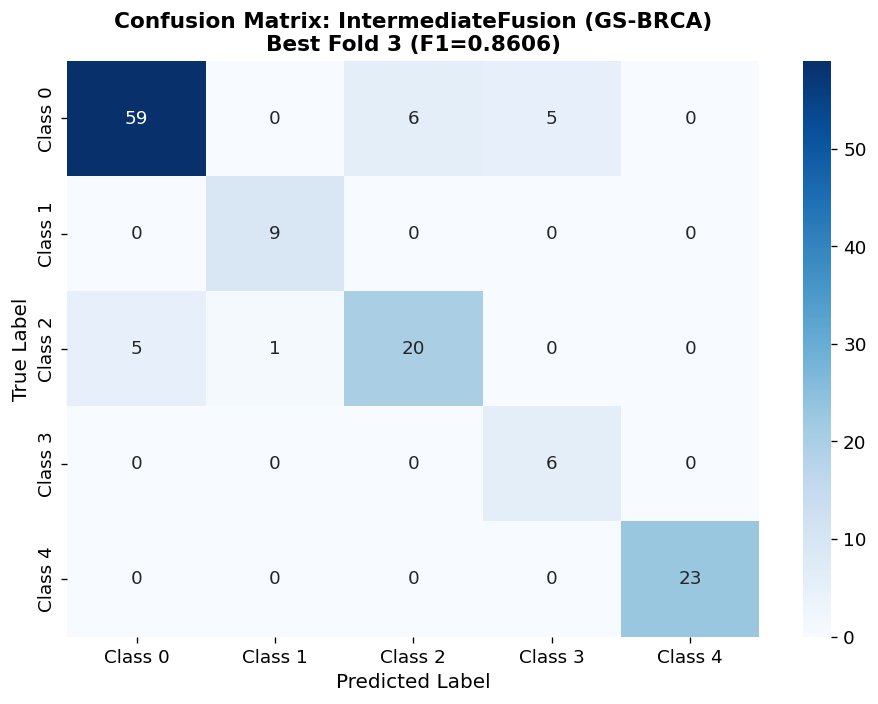

Best fold 3: 117/134 correct (87.3%)


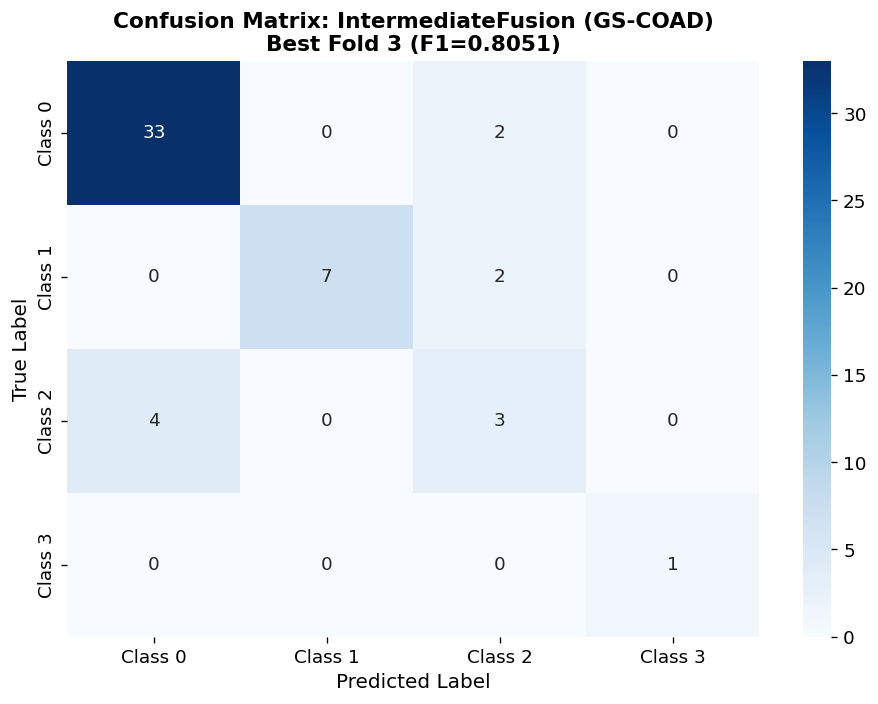

Best fold 3: 44/52 correct (84.6%)


In [12]:
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

for ct in CANCER_TYPES:
    cancer_short = ct.split('-')[1]
    cancer_lower = cancer_short.lower()

    # Find best fold by F1
    df = load_metrics('fusion', cancer_lower)
    fold_rows = df[df['fold'] != 'mean+/-std'].copy()
    fold_rows['f1'] = pd.to_numeric(fold_rows['f1'], errors='coerce')
    best_fold = int(fold_rows.loc[fold_rows['f1'].idxmax(), 'fold'])
    best_f1 = fold_rows['f1'].max()

    # Load predictions
    pred_path = os.path.join(METRICS_DIR, f'fusion_{cancer_lower}_fold{best_fold}_predictions.npz')
    if not os.path.exists(pred_path):
        print(f'Predictions not found: {pred_path}')
        continue

    data = np.load(pred_path)
    y_true, y_pred = data['y_true'], data['y_pred']
    n_classes_ct = len(np.unique(np.concatenate([y_true, y_pred])))

    cm = sk_confusion_matrix(y_true, y_pred, labels=list(range(n_classes_ct)))

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=[f'Class {i}' for i in range(n_classes_ct)],
        yticklabels=[f'Class {i}' for i in range(n_classes_ct)],
        ax=ax,
    )
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(
        f'Confusion Matrix: IntermediateFusion ({ct})\n'
        f'Best Fold {best_fold} (F1={best_f1:.4f})',
        fontsize=13, fontweight='bold',
    )
    plt.tight_layout()

    for ext in ['png', 'pdf']:
        fig.savefig(
            os.path.join(PLOTS_DIR, f'confusion_matrix_fusion_{cancer_short}.{ext}'),
            dpi=300, bbox_inches='tight', facecolor='white',
        )
    plt.show()
    print(f'Best fold {best_fold}: {np.sum(np.diag(cm))}/{np.sum(cm)} correct ({np.sum(np.diag(cm))/np.sum(cm):.1%})')

---
## 8b. Side-by-Side Confusion Matrices (All Models, Best Fold)

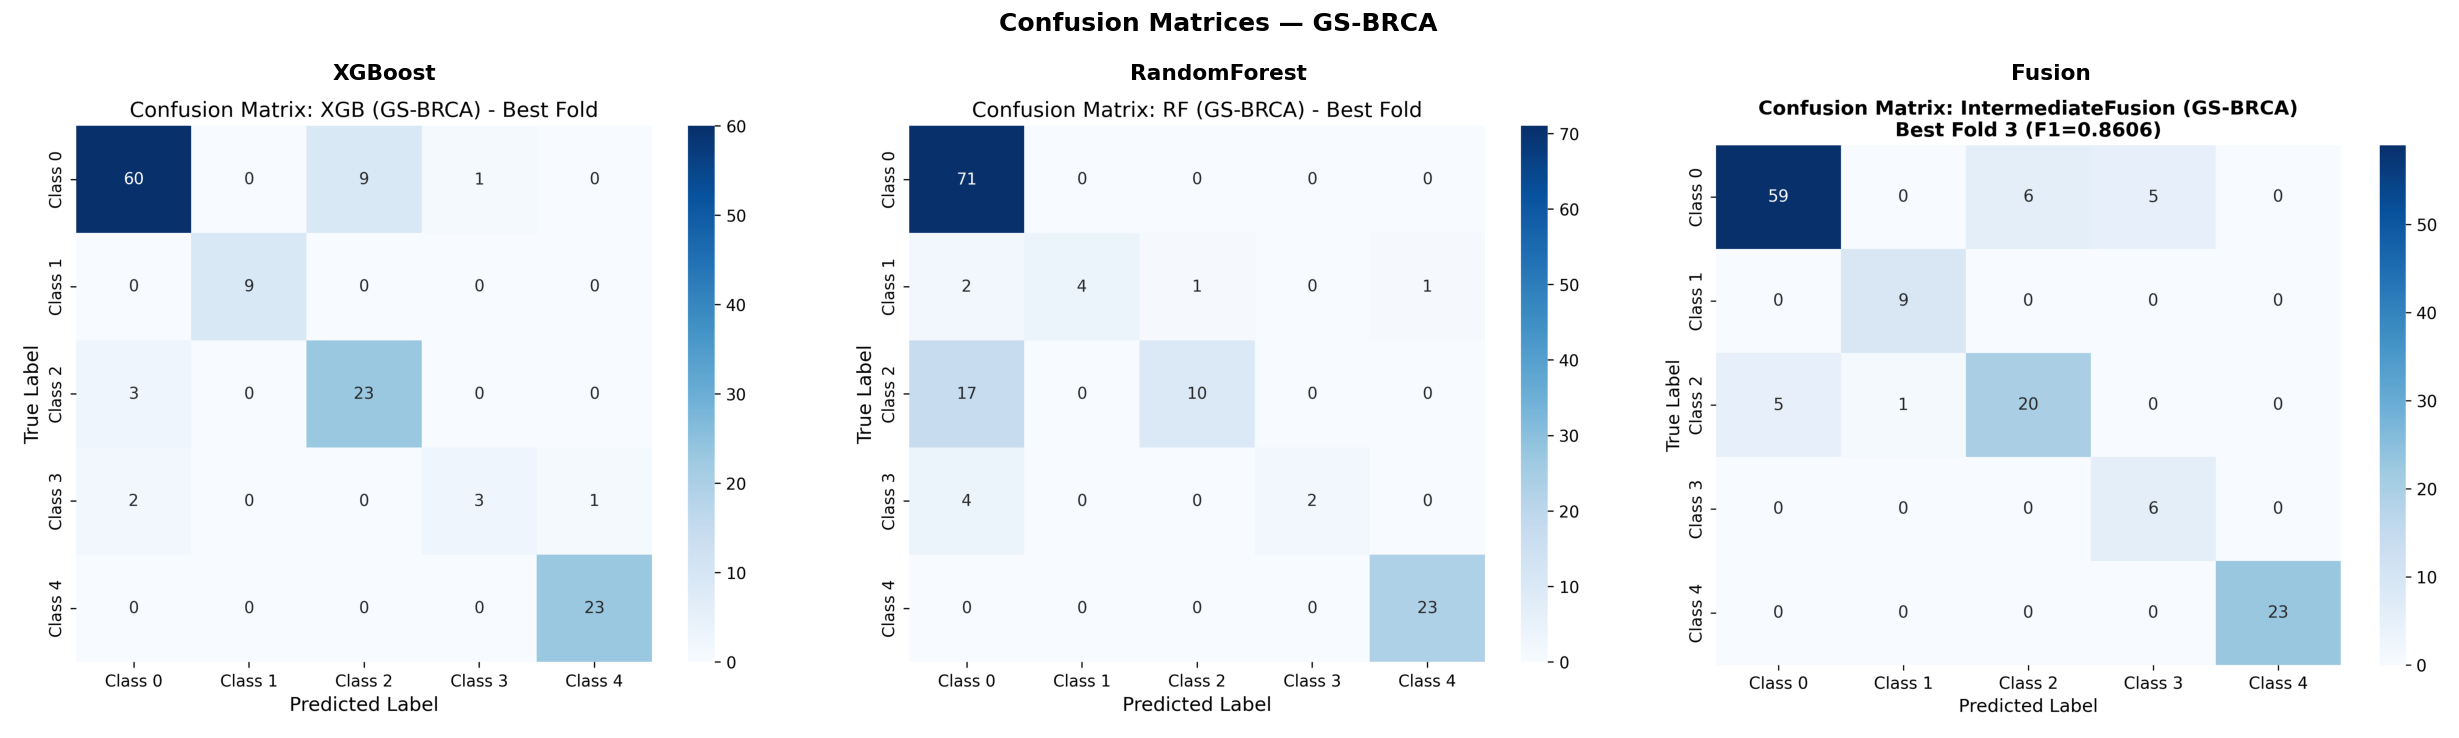

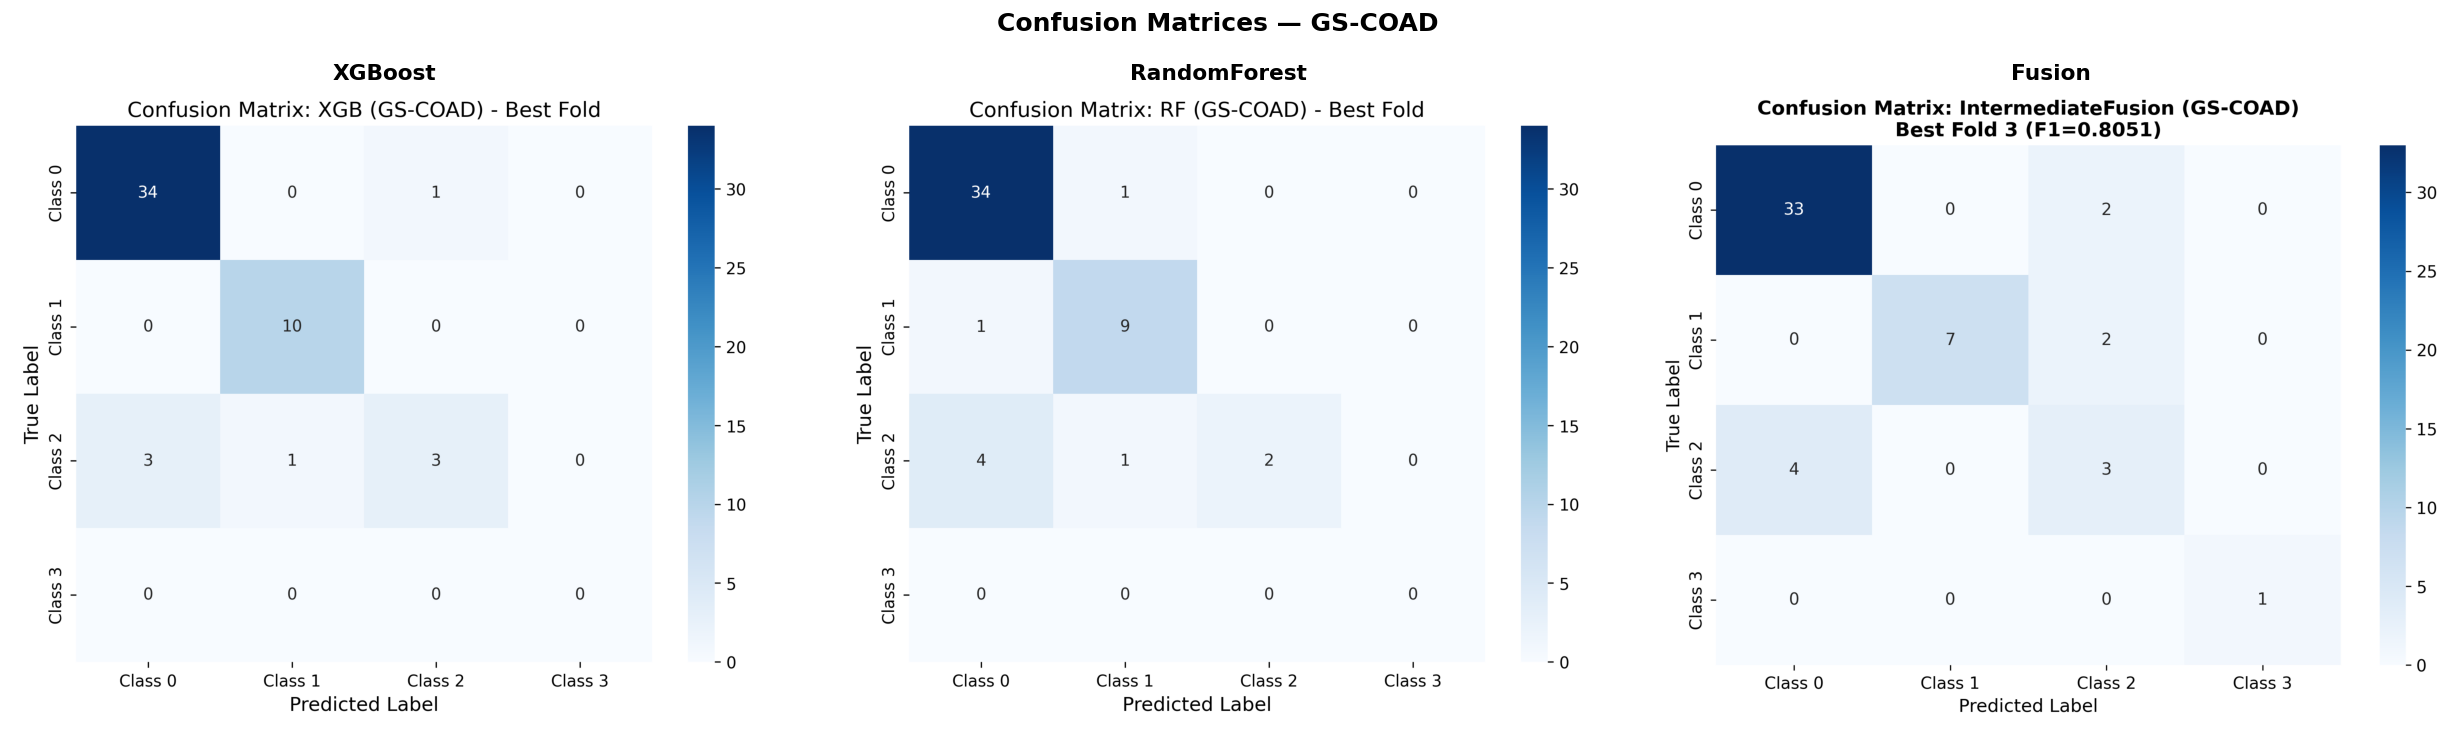

In [13]:
for ct in CANCER_TYPES:
    cancer_short = ct.split('-')[1]
    cm_files = {
        'XGBoost': os.path.join(PLOTS_DIR, f'confusion_matrix_xgb_{cancer_short}.png'),
        'RandomForest': os.path.join(PLOTS_DIR, f'confusion_matrix_rf_{cancer_short}.png'),
        'Fusion': os.path.join(PLOTS_DIR, f'confusion_matrix_fusion_{cancer_short}.png'),
    }

    existing = {k: v for k, v in cm_files.items() if os.path.exists(v)}
    if not existing:
        print(f'No confusion matrices found for {ct}')
        continue

    fig, axes = plt.subplots(1, len(existing), figsize=(7 * len(existing), 6))
    if len(existing) == 1:
        axes = [axes]

    for ax, (name, path) in zip(axes, existing.items()):
        img = plt.imread(path)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(name, fontsize=13, fontweight='bold')

    fig.suptitle(f'Confusion Matrices — {ct}', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

---
## 9. Discussion

### GS-BRCA (5 subtypes, ~670 samples)

| Model | F1 | Precision | Recall |
|---|---|---|---|
| **IntermediateFusion** | **0.8082±0.050** | 0.7917±0.043 | **0.8501±0.047** |
| XGBoost | 0.7939±0.047 | **0.8579±0.043** | 0.7745±0.047 |
| RandomForest | 0.6023±0.083 | 0.8001±0.135 | 0.5603±0.060 |

**The intermediate fusion model outperforms both baselines on F1 for BRCA.**

- Fusion achieves +1.4% F1 over XGBoost and +20.6% over RandomForest.
- The fusion model has notably higher **recall** (0.850 vs 0.775), meaning it
  correctly identifies more cancer subtypes — important for clinical sensitivity.
- XGBoost retains an edge in precision (0.858 vs 0.792), indicating fewer false
  positives per prediction.

### GS-COAD (4 subtypes, ~260 samples)

| Model | F1 | Precision | Recall |
|---|---|---|---|
| **IntermediateFusion** | **0.6691±0.094** | 0.6598±0.106 | **0.6930±0.082** |
| XGBoost | 0.6358±0.115 | 0.6694±0.126 | 0.6244±0.113 |
| RandomForest | 0.6083±0.073 | **0.6989±0.110** | 0.5950±0.067 |

**Fusion also leads on COAD** (+3.3% F1 over XGBoost, +6.1% over RF).

- Smaller dataset (260 samples) makes training harder for deep models, yet
  the fusion model still outperforms the tree-based baselines.
- Higher variance (±0.094) compared to BRCA is expected given the smaller sample size.
- XGBoost has better ARI (0.737 vs 0.608) and NMI (0.660 vs 0.548) on COAD,
  suggesting the tree model finds cleaner cluster separations on this small dataset.

### Why Does Fusion Win on F1?

1. **Intermediate fusion learns modality-specific representations** rather than
   simply concatenating raw features. Each encoder can capture non-linear
   patterns within its modality before fusion.
2. **Latent dimensionality reduction** (15,200 features → 256 total latent dims)
   forces the model to learn compact representations, reducing noise.
3. **Class-weighted loss** combined with the neural network's flexibility helps
   handle the imbalanced subtype distributions (e.g., Basal vs Normal-like).

### Limitations

- Features were pre-selected via global ANOVA (known limitation of the MLOmics
  benchmark), which may bias all models toward the same discriminative features.
- The fusion model's advantage is modest on BRCA (+1.4% F1) — within the
  standard deviation, so statistically not definitive.
- Hyperparameter tuning was limited (fixed latent_dim=64); exploring the
  candidate dimensions [32, 64, 128] might yield further improvements.

> *Academic research prototype. Not for clinical use.*

In [15]:
# Final summary printout
print('=' * 60)
print('Latent Fusion Notebook — Complete')
print('=' * 60)
print(f'model_comparison.csv: {csv_path}')
for ct in CANCER_TYPES:
    cs = ct.split('-')[1]
    print(f'  model_comparison_{cs}.png/pdf')
    print(f'  confusion_matrix_fusion_{cs}.png/pdf')
print('\nAll figures exported at 300 DPI (PNG) + vector (PDF) for thesis.')

Latent Fusion Notebook — Complete
model_comparison.csv: results\metrics\model_comparison.csv
  model_comparison_BRCA.png/pdf
  confusion_matrix_fusion_BRCA.png/pdf
  model_comparison_COAD.png/pdf
  confusion_matrix_fusion_COAD.png/pdf

All figures exported at 300 DPI (PNG) + vector (PDF) for thesis.
